In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('../src/')

In [2]:
import utils
import importlib
importlib.reload(utils)

<module 'utils' from '/mnt/windows/Linux_Wind_Shared/GalaxyFormation_FullProject/Notebooks/../src/utils.py'>

In [3]:
h = 0.67 

Om_m = 0.315            # matter density
Om_b = 0.022/(h*h)      # baryonic matter density
Om_lambda = 0.685       # vacuum energy density

rho_c = 2.78e11 *h*h    # in units of M_s/Mpc^3

# mean matter density of the universe
rho_0 = Om_m * rho_c    # in units of M_s/Mpc^3
delta_c = 1.686         # Critical density for spherical collapse

# for normalising the power spectrum
sigma8_obs = 0.811      # Observed value of sigma_8
n = 0.965               # power spectrum P(k)~ k^n

z_range = np.linspace(0.1,20, 100)

from numba import jit

f_b = Om_b/Om_m     # fraction of baryonic matter
H0 = h/9.78e9         # in units of 1/yr

#  Accretion Shocks

## Relativistic Electron Energy Density

In [4]:
def E_bb(M, z): #Baryon binding energy of a halo of mass M (in SM) at redshift z in erg
    Om_m_z = Om_m * (1 + z) ** 3 / (Om_m * (1 + z) ** 3 + Om_lambda)
    d = Om_m_z - 1
    delta_c = 18 * np.pi ** 2 + 82 * d - 39 * d ** 2
    baryon_frac = Om_b / Om_m #Need only baryon binding energy
    return 5.45 * 10 ** (53) * (M * h / 10 ** 8) ** (5 / 3) * (Om_m / Om_m_z * delta_c / (18 * np.pi ** 2)) ** (1 / 3) * (1 + z) / (10 * h) * baryon_frac

In [5]:
min_T_vir = 10 ** 4 #Efficient atomic cooling above this temp

neutral_mu = 1.23
k_B_SI = 1.38 * 10 ** (-23) #m^2 kg s^-2 K^-1
m_p_kg = 1.67 * 10 ** (-27) #kg

min_V_c = np.sqrt(min_T_vir * 2 * (k_B_SI / (1000) ** 2) / (neutral_mu * m_p_kg))

def M_factor(z): #The coefficient of M^1/3 in V_c formula
    Om_m_z = Om_m * (1 + z) ** 3 / (Om_m * (1 + z) ** 3 + Om_lambda)
    d = Om_m_z - 1
    delta_c = 18 * np.pi ** 2 + 82 * d - 39 * d ** 2
    return 23.4 * (Om_m / Om_m_z * delta_c / (18 * np.pi ** 2)) ** (1 / 6) * ((1 + z) / 10) ** (1 / 2) / (10 ** 8 * h ** (-1)) ** (1 / 3)

def M_crit(z):
    return (min_V_c / M_factor(z)) ** (3)

In [6]:
M_range = np.logspace(6, 16, 500)  # Mass range in solar masses

M_arrs_inz = [] #Mass range set by V_c critical

for i in range(len(z_range)):
    arr = np.logspace(np.log10(M_crit(z_range[i])), 16, 500)
    M_arrs_inz.append(arr)

M_arrs_inz = np.array(M_arrs_inz)

In [7]:
from utils import PS_MassFunc

In [8]:
dn_dlogM_new = np.zeros((len(M_range), len(z_range)))
integrand_rel_en_dens = np.zeros((len(M_range), len(z_range)))

f_r = 0.1 #fraction of binding energy going into relativistic electrons

for i in range(len(z_range)):
    for j in range(len(M_range)):
        dn_dlogM_new[j, i] = PS_MassFunc(M_arrs_inz[i][j], z_range[i]) * (rho_0 / M_arrs_inz[i][j])
        integrand_rel_en_dens[j, i] = dn_dlogM_new[j, i] * f_r * E_bb(M_arrs_inz[i][j], z_range[i])

In [9]:
Rel_energy_dens = np.trapezoid(integrand_rel_en_dens, x=np.log10(M_range), axis=0)

Text(0.5, 0, '$z$')

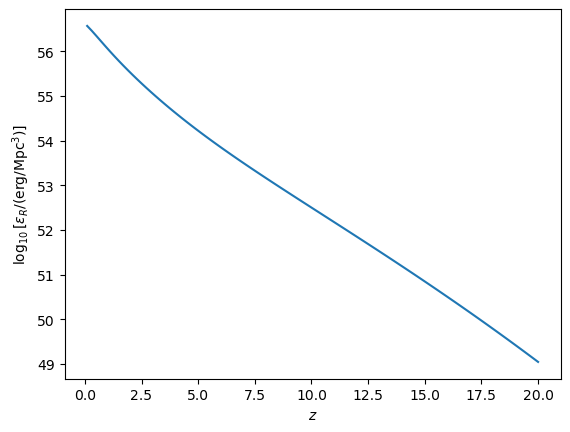

In [10]:
plt.plot(z_range, np.log10(Rel_energy_dens))
plt.ylabel(r'$\log_{10}[\epsilon_R/(\text{erg/Mpc}^{3})]$')
plt.xlabel(r'$z$')
#plt.title(r'')

## Thermal Background Energy Density

In [11]:
def n_gas(z):
    neutral_mu = 1.23
    m_p = 1.67 * 10 ** (-27) * (5.03 * 10 ** (-31)) #Solar mass
    rho_b0 = Om_b * rho_c
    n_0 = rho_b0 / (neutral_mu * m_p)
    return n_0

In [12]:
n_arr = np.zeros_like(z_range)

for i in range(len(z_range)):
    n_arr[i] = n_gas(z_range[i])

Text(0, 0.5, '$n_\\text{gas}(z)$ (Mpc$^{-3}$)')

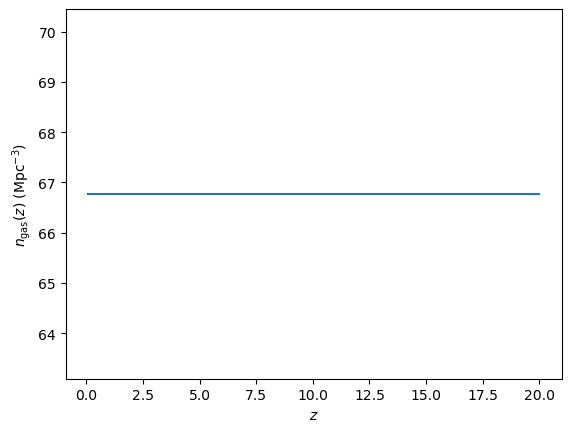

In [13]:
plt.plot(z_range, np.log10(n_arr))
plt.xlabel(r'$z$')
plt.ylabel(r'$n_\text{gas}(z)$ (Mpc$^{-3}$)')

In [14]:
def E_thermal_dens(z, T): #Inputing z and T arr we have already calculated
    k_B = 1.38 * 10 ** (-16) #in CGS
    neutral_mu = 1.23
    m_p = 1.67 * 10 ** (-27) * (5.03 * 10 ** (-31)) #Solar mass
    rho_b0 = Om_b * rho_c
    n_0 = rho_b0 / (neutral_mu * m_p)
    T_arr = np.zeros_like(z)
    for i in range(len(z)):
        T_arr[i] = 3 / 2 * n_0 * k_B * T
    return T_arr

In [15]:
Thermal_energy_dens1 = E_thermal_dens(z_range, 10)
Thermal_energy_dens2 = E_thermal_dens(z_range, 100)
Thermal_energy_dens3 = E_thermal_dens(z_range, 10**4)

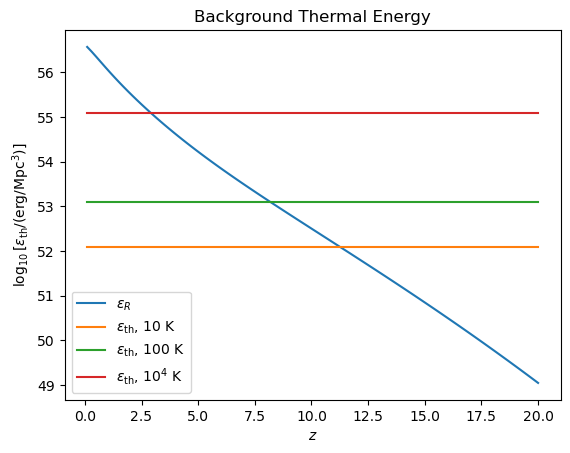

In [16]:
plt.plot(z_range, np.log10(Rel_energy_dens), label = r'$\epsilon_R$')
plt.plot(z_range, np.log10(Thermal_energy_dens1), label = r'$\epsilon_\text{th}$, 10 K')
plt.plot(z_range, np.log10(Thermal_energy_dens2), label = r'$\epsilon_\text{th}$, 100 K')
plt.plot(z_range, np.log10(Thermal_energy_dens3), label = r'$\epsilon_\text{th}$, $10^4$ K')
plt.xlabel(r'$z$')
plt.ylabel(r'$\log_{10}[\epsilon_\text{th}/(\text{erg/Mpc}^3)]$')
plt.title(r'Background Thermal Energy')
plt.legend()

In [17]:
Energy_dens_ratio1 = Rel_energy_dens / Thermal_energy_dens1
Energy_dens_ratio2 = Rel_energy_dens / Thermal_energy_dens2
Energy_dens_ratio3 = Rel_energy_dens / Thermal_energy_dens3

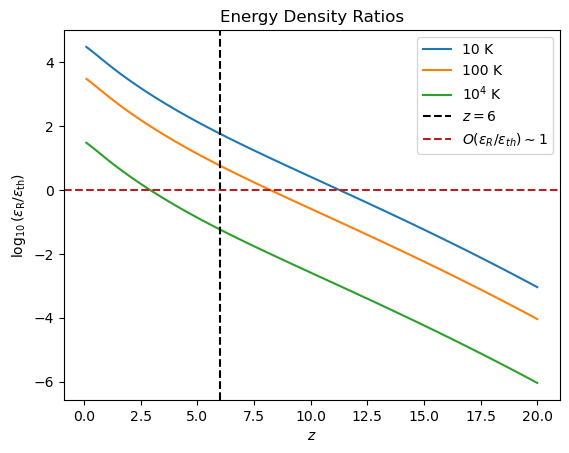

In [18]:
plt.plot(z_range, np.log10(Energy_dens_ratio1), label = r'10 K')
plt.plot(z_range, np.log10(Energy_dens_ratio2), label = r'100 K')
plt.plot(z_range, np.log10(Energy_dens_ratio3), label = r'$10^4$ K')
plt.xlabel(r'$z$')
plt.ylabel(r'$\log_{10}(\epsilon_\text{R}/\epsilon_\text{th})$')
plt.title(r'Energy Density Ratios')
plt.axvline(6, ls = '--', color = r'black', label = r'$z=6$')
plt.axhline(0, ls = '--', color = r'firebrick', label = r'$O(\epsilon_R/\epsilon_{th})\sim1$')
plt.legend()

In [19]:
crossings = np.where(np.diff(np.sign(Energy_dens_ratio3 - 1)))[0]

z_cross = z_range[crossings[0]]
print(z_cross)

2.713131313131313


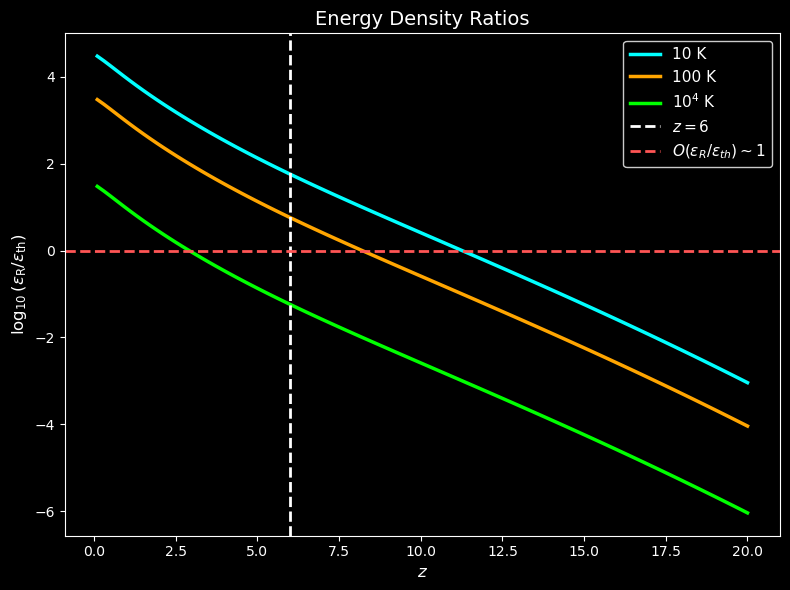

In [20]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(8,6))
fig.patch.set_facecolor('black')
ax.set_facecolor('black')

# --- Curves ---
ax.plot(z_range, np.log10(Energy_dens_ratio1),
        label=r'10 K', color='#00FFFF', lw=2.5)   # cyan

ax.plot(z_range, np.log10(Energy_dens_ratio2),
        label=r'100 K', color='#FFA500', lw=2.5)  # orange

ax.plot(z_range, np.log10(Energy_dens_ratio3),
        label=r'$10^4$ K', color='#00FF00', lw=2.5)  # green

# --- Reference lines (made visible on dark bg) ---
ax.axvline(6, ls='--', color='white', lw=2, label=r'$z=6$')

ax.axhline(0, ls='--', color='#FF5555', lw=2,
           label=r'$O(\epsilon_R/\epsilon_{th})\sim1$')

# --- Labels & title ---
ax.set_xlabel(r'$z$', fontsize=12, color='white')
ax.set_ylabel(r'$\log_{10}(\epsilon_\text{R}/\epsilon_\text{th})$', fontsize=12, color='white')
ax.set_title(r'Energy Density Ratios', fontsize=14, color='white')

# --- Ticks ---
ax.tick_params(colors='white')

# --- Spines ---
for spine in ax.spines.values():
    spine.set_color('white')

# --- Legend ---
legend = ax.legend(facecolor='black', edgecolor='white', fontsize=11)
for text in legend.get_texts():
    text.set_color('white')

plt.tight_layout()
plt.show()

# Emissivity Comparizon Plot

## HMXBS

In [21]:
from utils import Madau

In [22]:
SFRD_vals = np.zeros_like(z_range)
HMXB_Em_vals = np.zeros_like(z_range)

L_HMXB = 10 ** (40)

for i in range(len(z_range)):
    SFRD_vals[i] = Madau(z_range[i])
    HMXB_Em_vals[i] = L_HMXB * SFRD_vals[i]

## LMXBs

In [23]:
def H(z): #in km/s/Mpc
    return 67 * np.sqrt( Om_m*(1+z)**3 + Om_lambda )

Mpctokm = 3.086 * 10 ** (19)
SectoYr = 1 / (3.154 * 10 ** 7)

def dt_dz(z): #In yr
    return -1 / ((1 + z) * H(z) / (SectoYr * Mpctokm))

In [24]:
def LM_Int(z):
    return Madau(z) * np.abs(dt_dz(z))

In [25]:
LM_Int_vals = np.zeros_like(z_range)

for i in range(len(z_range)):
    LM_Int_vals[i] = LM_Int(z_range[i])

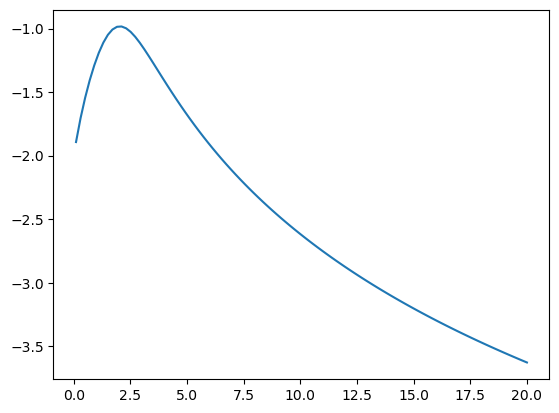

In [26]:
Madau_vals = Madau(z_range)

plt.plot(z_range, np.log10(Madau_vals))

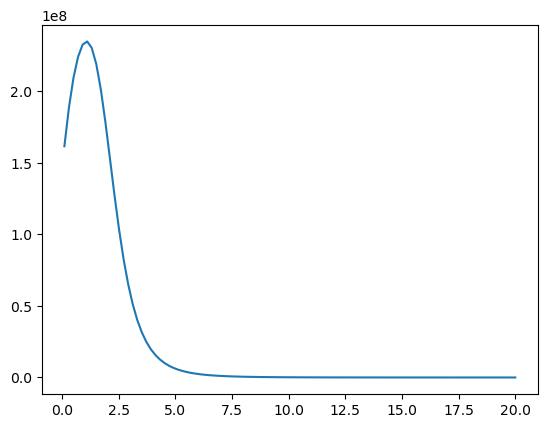

In [27]:
plt.plot(z_range, LM_Int_vals)

In [28]:
from scipy.integrate import cumulative_trapezoid

In [29]:
z = z_range                # ascending: 0 → 20
f = LM_Int(z)

# cumulative integral from 0 → z
cum_int = cumulative_trapezoid(f, z, initial=0)

# total integral from 0 → 20
total = cum_int[-1]

# desired: integral from z → 20
F = total - cum_int

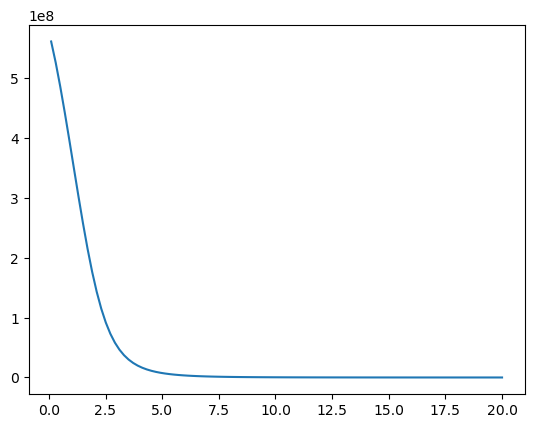

In [30]:
plt.plot(z_range, F)

In [31]:
L_LMXB = 10 ** (30.5)

Ret_fact = 0.39

LMXB_Em_vals = L_LMXB * F * (1 - Ret_fact)

## Accretion Shocks

In [32]:
Yrtosec = 3.154 * 10 ** 7
Mpctokm = 3.086 * 10 ** (19)

def Time_ff(z):
    return 1 / np.sqrt(27 * np.pi ** 2 * (H(z) / Mpctokm) ** 2)

In [33]:
Time_ff(0)

np.float64(2.8215604830375628e+16)

In [34]:
Time_ff_vals = Time_ff(z_range)

AccShocks_Em_vals = Rel_energy_dens / Time_ff_vals

/tmp/ipykernel_119275/2454027738.py:1: RuntimeWarning: divide by zero encountered in log10
  plt.plot(z_range, np.log10(LMXB_Em_vals), label = r'LMXB')


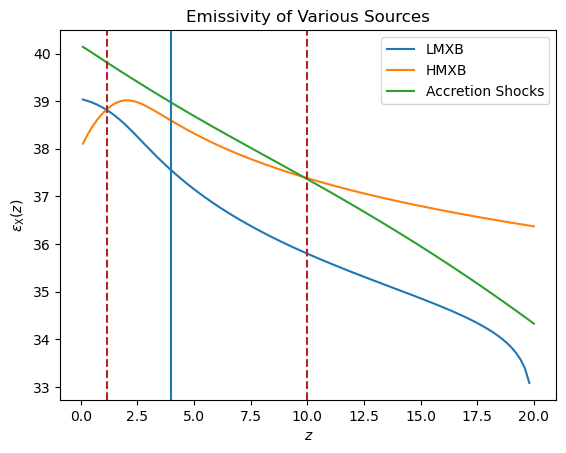

In [39]:
plt.plot(z_range, np.log10(LMXB_Em_vals), label = r'LMXB')
plt.plot(z_range, np.log10(HMXB_Em_vals), label = r'HMXB')
plt.plot(z_range, np.log10(AccShocks_Em_vals), label = r'Accretion Shocks')

plt.xlabel(r'$z$')
plt.ylabel(r'$\epsilon_\text{X}(z)$')
plt.title(r'Emissivity of Various Sources')
plt.legend()
plt.axvline(10, ls = '--', color = r'firebrick')
plt.axvline(1.15, ls = '--', color = r'firebrick')
plt.axvline(4)

/tmp/ipykernel_119275/1148390463.py:9: RuntimeWarning: divide by zero encountered in log10
  ax.plot(z_range, np.log10(LMXB_Em_vals),


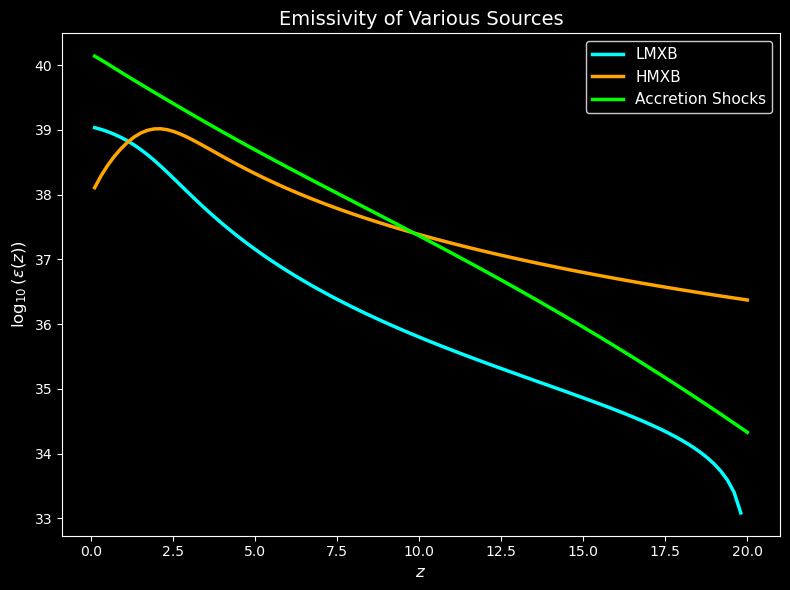

In [36]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(8,6))
fig.patch.set_facecolor('black')
ax.set_facecolor('black')

# --- Curves ---
ax.plot(z_range, np.log10(LMXB_Em_vals),
        label=r'LMXB', color='#00FFFF', lw=2.5)   # cyan

ax.plot(z_range, np.log10(HMXB_Em_vals),
        label=r'HMXB', color='#FFA500', lw=2.5)   # orange

ax.plot(z_range, np.log10(AccShocks_Em_vals),
        label=r'Accretion Shocks', color='#00FF00', lw=2.5)  # green

# --- Vertical line (visible on dark bg) ---
#ax.axvline(10, linestyle='--', color='white', lw=2)

# --- Labels & title ---
ax.set_xlabel(r'$z$', fontsize=12, color='white')
ax.set_ylabel(r'$\log_{10}(\epsilon(z))$', fontsize=12, color='white')
ax.set_title(r'Emissivity of Various Sources', fontsize=14, color='white')

# --- Ticks ---
ax.tick_params(colors='white')

# --- Spines ---
for spine in ax.spines.values():
    spine.set_color('white')

# --- Legend ---
legend = ax.legend(facecolor='black', edgecolor='white', fontsize=11)
for text in legend.get_texts():
    text.set_color('white')

plt.tight_layout()
plt.show()

## Accretion Shocks Spectrum Calculation

In [37]:
#Number density of accelerated electrons

gamma_min = 10 ** 2
gamma_max = 10 ** 3

sp_ind = 3 #spectral index

m_e = 9.11 * 10 ** (-31) #kg
sp_light = 3 * 10 ** 8 #m/s

En_const = m_e * sp_light ** 2 * 10 ** 7 #erg

N_e0_acc = (gamma_min ** (sp_ind - 2) * (sp_ind - 2) * Rel_energy_dens) / (En_const)

In [38]:
def N_e_acc(N_e0_acc_arr, gamma_min_val, gamma_max_val):
    gamma_arr = np.linspace(gamma_min_val, gamma_max_val)
    N_arr = np.zeros((len(gamma_arr), len(N_e0_acc_arr)))
    